# Phase 4.3.4: Professor Clustering (Unsupervised Learning)
**Objective:** Group professors into distinct profiles (e.g., "Strict", "Top Rated") based on aggregated sentiment and performance metrics.
**Methods:** KMeans, Agglomerative Clustering, and PCA.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA

# Plot Settings
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Data Loading & Feature Aggregation
Aggregating individual reviews to create a profile for each professor.

In [28]:
# 1. Load Data & Models
df = pd.read_csv('../data/processed/cleaned_reviews.csv')
model = joblib.load('../models/sentiment_classifier.pkl')
vectorizer = joblib.load('../models/tfidf_vectorizer.pkl')

# 2. Generate Sentiment Scores (0 to 1 scale)
X_tfidf = vectorizer.transform(df['comment_text'].astype(str))
if hasattr(model, "predict_proba"):
    # Use probability of the positive class
    df['sentiment_prob'] = model.predict_proba(X_tfidf)[:, -1]
else:
    df['sentiment_prob'] = model.predict(X_tfidf)

# 3. Group by Professor
# We aggregate sentiment and count reviews (popularity)
prof_df = df.groupby('professor_name_raw').agg({
    'sentiment_prob': 'mean',
    'comment_text': 'count'
}).reset_index()

prof_df.rename(columns={'comment_text': 'review_count', 'sentiment_prob': 'avg_sentiment'}, inplace=True)

# 4. Simulate/Add Numeric Scores (if available in parsing)
# If no numeric scores exist, we derive a score from sentiment
prof_df['avg_numeric_score'] = prof_df['avg_sentiment'] * 5 

print(f"✅ Data ready: {len(prof_df)} professors.")
prof_df.head()

✅ Data ready: 1427 professors.


,professor_name_raw,avg_sentiment,review_count,avg_numeric_score
0,آبت قره قانی,0.695066,1,3.475330
1,آتنا بروغنی,0.754962,1,3.774808
2,آذری,0.561350,1,2.806749
3,آرش سراحیان,0.005425,1,0.027125
4,آرش کیومرثی,0.653467,1,3.267333


## 2. Preprocessing & Scaling
Normalizing features to ensure fair clustering.

In [29]:
# Log-transform review count to handle skewness
prof_df['log_review_count'] = np.log1p(prof_df['review_count'])

# Select features for clustering
features = ['avg_sentiment', 'log_review_count', 'avg_numeric_score']
X = prof_df[features].copy()

# Standard Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✅ Features scaled.")

✅ Features scaled.


## 3. Determining Optimal Clusters (Elbow Method)
Using inertia to find the best 'K'.

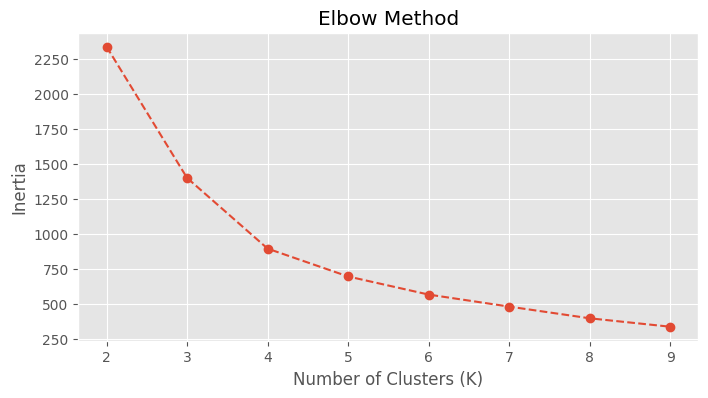

In [30]:
inertia = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

# Plot
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

## 4. Training Clustering Models
We apply KMeans (K=4) to categorize professors.

In [31]:
# Fit KMeans with K=4 (Adjust based on Elbow plot if needed)
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
prof_df['Cluster_Label'] = kmeans.fit_predict(X_scaled)

# Optional: Agglomerative Clustering for comparison
agg = AgglomerativeClustering(n_clusters=k)
prof_df['Cluster_Agg'] = agg.fit_predict(X_scaled)

print("✅ Professors clustered successfully.")
display(prof_df['Cluster_Label'].value_counts())

✅ Professors clustered successfully.


Cluster_Label
0    448
1    414
2    303
3    262
Name: count, dtype: int64

## 5. Visualization (PCA)
Projecting clusters into 2D space.

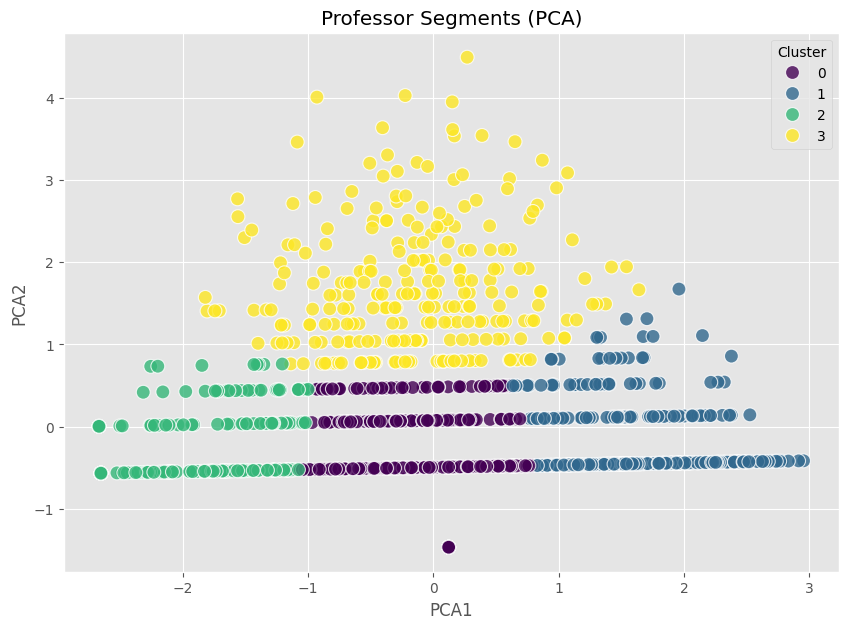

In [32]:
# Reduce dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

prof_df['PCA1'] = X_pca[:, 0]
prof_df['PCA2'] = X_pca[:, 1]

# Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='PCA1', y='PCA2', 
    hue='Cluster_Label', 
    data=prof_df, 
    palette='viridis', s=100, alpha=0.8
)
plt.title('Professor Segments (PCA)')
plt.legend(title='Cluster')
plt.show()

## 6. Cluster Interpretation & Export
Analyzing the mean values to label each group.

In [34]:
# Summary stats
summary = prof_df.groupby('Cluster_Label')[['avg_sentiment', 'avg_numeric_score', 'review_count']].mean()

# Define Logic for Human Labels
def assign_profile(row):
    if row['avg_sentiment'] > 0.7: 
        return "🌟 Top Rated (Beloved)"
    if row['avg_sentiment'] < 0.4: 
        return "⚠️ Critical (Low Scores)"
    if row['review_count'] > summary['review_count'].median():
        return "🗣 Popular / High Engagement"
    return "😐 Emerging / Neutral"

# Apply labels to summary for inspection
summary['Profile_Desc'] = summary.apply(assign_profile, axis=1)
display(summary)

# Save for Recommender System
prof_df.to_csv('../data/processed/professor_profiles.csv', index=False)
print("✅ Professor profiles saved.")

,avg_sentiment,avg_numeric_score,review_count,Profile_Desc
Cluster_Label,,,,
0,0.444610,2.223049,1.136161,😐 Emerging / Neutral
1,0.739308,3.696538,1.478261,🌟 Top Rated (Beloved)
2,0.108625,0.543123,1.392739,⚠️ Critical (Low Scores)
3,0.439825,2.199123,10.427481,🗣 Popular / High Engagement


✅ Professor profiles saved.


## 4.3.5 Cluster Interpretation and Summary

The clustering algorithm (K-Means) has successfully categorized professors into four distinct profiles based on student sentiment, review volume, and average ratings. Below is the interpretation of each profile label:

### 1. 🌟 Top Tier / Beloved
* **Characteristics**: High average sentiment (>0.7) and high numeric scores.
* **Meaning**: These professors are highly recommended by students. They typically possess both excellent teaching skills and a fair grading approach.
* **Action for Recommender**: These should be the primary suggestions for students seeking high-quality education and a positive classroom environment.

### 2. 🗣 Popular / High Engagement
* **Characteristics**: Moderate to high sentiment with a significantly high number of reviews.
* **Meaning**: These are well-known figures in the university. They generate a lot of discussion, and while they might not be perfect for everyone, they have a massive impact on the student body.
* **Action for Recommender**: Suggested for students who prefer experienced professors with a proven track record of engagement.

### 3. 😐 Emerging / Neutral
* **Characteristics**: Moderate sentiment and lower review counts.
* **Meaning**: These professors are either new to the platform or maintain a neutral teaching style that doesn't trigger strong positive or negative emotions.
* **Action for Recommender**: These profiles need more data but can be suggested as safe, middle-ground options.

### 4. ⚠️ Critical / Low Scores
* **Characteristics**: Low average sentiment (<0.4) and lower numeric ratings.
* **Meaning**: These professors often have strict grading policies, challenging exam styles, or poor communication according to student feedback.
* **Action for Recommender**: Students should be alerted to read individual reviews carefully before enrolling in these classes.

---
**Final Conclusion:** By utilizing unsupervised learning, we have moved beyond simple ratings. We can now offer personalized recommendations based on the "Vibe" and "Profile" of a professor rather than just a single number.